# XAI CODE DEMO
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/dev/interpretable-ml-example-notebooks/regression-interpretability.ipynb)

# Logistic Regression for Interpretability

* **Logistic Regression**: Coefficients describe the change in the **log-odds** of churn; exponentiating a coefficient gives an **odds ratio**, directly interpretable as "how much do the odds of churn multiply for a one-unit increase in this feature?"

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

We will use the [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) dataset [LINK]. Each row is one telecom customer; the target is `Churn` (`Yes`/`No`). **Goal:** build an interpretable model of churn using Logistic Regression, and identify the assumptions the telecom should worry about before acting on the model's explanations.

### 🛑 CHECK ASSUMPTIONS!

Note: Your homework requires you to use appropriate visualizations and statistical methods to determine whether assumptions about linear, logistic, and GAM models are met. These are not included in this notebook by default but are required when building regression models (or any models! always check your assumptions).

Assumptions for **logistic regression** (different from linear regression's OLS assumptions):

**Binary (or ordinal/nominal) Outcome, Correctly Coded**
The outcome must be categorical, coded as 0/1 for binary logistic regression.

How to Test:
- Confirm the outcome has exactly two levels and check their coding
- `value_counts()` on the raw and mapped target

Remedies if Violated:
- Recode the outcome, or use multinomial/ordinal logistic regression for >2 categories

**Independence of Observations**
Observations should be independent of each other.

How to Test:
- Check whether rows represent repeated measurements or clustering (e.g., shared households/accounts)

Remedies if Violated:
- Use clustered/robust standard errors, or a mixed-effects model

**No (Severe) Multicollinearity**
Predictors should not be highly correlated with each other.

How to Test:
- Correlation matrix
- Variance Inflation Factor (VIF) on the full encoded design matrix

Remedies if Violated:
- Remove/combine correlated predictors

**Linearity of the Logit**
Logistic regression assumes a **linear relationship between continuous predictors and the log-odds (logit)** of the outcome — not between the predictor and the raw probability.

How to Test:
- Empirical logit plots (binned mean of X vs. log-odds of the outcome)
- Box-Tidwell test

Remedies if Violated:
- Add polynomial/spline terms, bin the variable, or use a model that doesn't assume linearity in the logit (e.g., GAM)

**Sufficient Sample Size (Events per Variable)**
Rule of thumb: at least ~10 events (the rarer outcome class) per predictor.

How to Test:
- Count events, divide by number of predictors after encoding

Remedies if Violated:
- Reduce the number of predictors, or use penalized regression

**No Influential Outliers**
No single observation should dominate the fitted coefficients.

How to Test:
- Cook's distance on the fitted model

Remedies if Violated:
- Investigate and consider removing/down-weighting influential points

In [2]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Before cleaning anything, let's look at the structure: shape, dtypes, and columns.

In [3]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.info()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null

`TotalCharges` is showing up as `str`/object instead of a number — that's the first thing we'll fix. Now let's clean the data.

In [4]:
# Clean the data
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df = df.drop(columns=["customerID"])  # unique identifier, no predictive value


no_internet_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]
for col in no_internet_cols:
    df[col] = df[col].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

# Binary target
df["target"] = df["Churn"].map({"No": 0, "Yes": 1})

print(f"Shape after cleaning: {df.shape}")
df.head()

Shape after cleaning: (7032, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,target
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## EDA Relevant to Logistic Regression Assumptions

### Independence of Observations

Each row in this dataset is a different customer, and there's no repeated rows for the same customer or obvious grouping (like multiple accounts from the same household). So it's reasonable to treat the observations as independent.

target
0    0.734215
1    0.265785
Name: proportion, dtype: float64


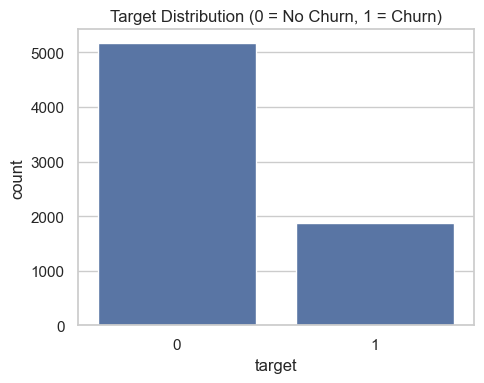

In [5]:
print(df["target"].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="target")
plt.title("Target Distribution (0 = No Churn, 1 = Churn)")
plt.tight_layout()
plt.show()

Churn is imbalanced

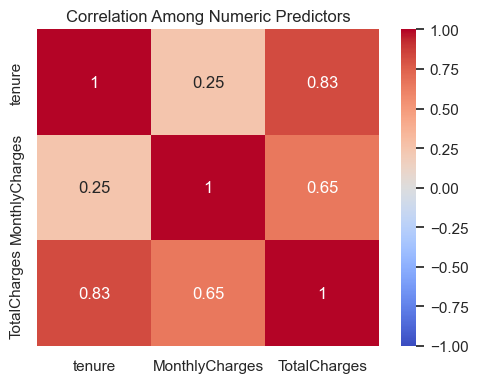

,feature,VIF
3,MonthlyCharges,866.089640
10,InternetService_Fiber optic,148.500814
11,InternetService_No,104.213701
8,PhoneService_Yes,34.893857
17,StreamingMovies_Yes,24.156394
16,StreamingTV_Yes,24.080019
4,TotalCharges,10.811490
2,tenure,7.584453
9,MultipleLines_Yes,7.289761
14,DeviceProtection_Yes,6.924754


In [6]:
# Multicollinearity check: correlation among numeric predictors, then VIF across the
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Among Numeric Predictors")
plt.tight_layout()
plt.show()

X_vif = pd.get_dummies(df.drop(columns=["Churn", "target"]), drop_first=True).astype(
    float
)
X_vif_const = sm.add_constant(X_vif)
vif_df = pd.DataFrame(
    {
        "feature": X_vif_const.columns,
        "VIF": [
            variance_inflation_factor(X_vif_const.values, i)
            for i in range(X_vif_const.shape[1])
        ],
    }
)
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
vif_df.head(10)

### Multicollinearity Check

Multicollinearity was checked using a correlation matrix and Variance Inflation Factor (VIF).

The correlation matrix shows a strong relationship between tenure and TotalCharges (correlation = 0.83). This is expected because customers who stay longer usually have higher total charges.

The VIF analysis also shows high values for some features, especially MonthlyCharges and variables related to InternetService. This means some predictors contain similar information.

Because some features overlap, the logistic regression coefficients should be interpreted carefully. The model can still make useful predictions, but we should be careful when explaining the effect of individual features.

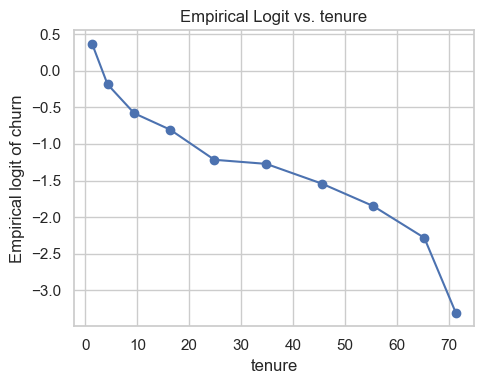

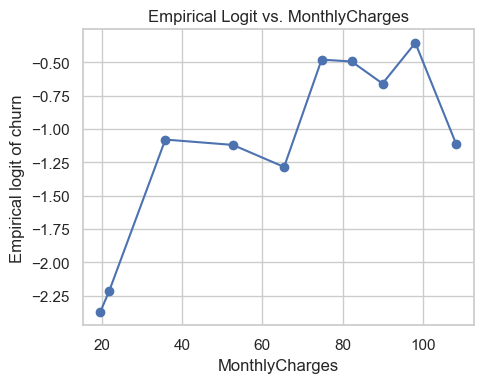

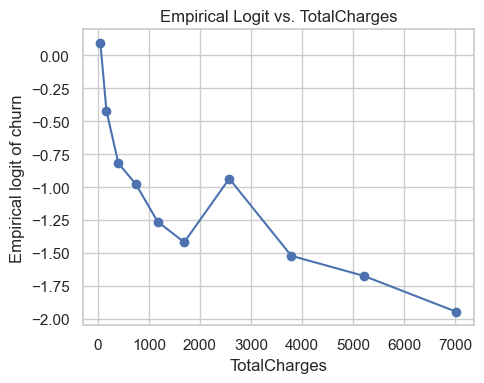

In [7]:
# Linearity-of-the-logit check: bin each continuous predictor, compute the empirical


def empirical_logit_plot(data, x_col, y_col="target", bins=10):
    tmp = data[[x_col, y_col]].copy()
    tmp["bin"] = pd.qcut(tmp[x_col], q=bins, duplicates="drop")
    grouped = tmp.groupby("bin", observed=True).agg(
        x_mean=(x_col, "mean"),
        churn_rate=(y_col, "mean"),
        n=(y_col, "size"),
    )
    eps = 0.5 / grouped["n"]
    p = grouped["churn_rate"].clip(eps, 1 - eps)
    grouped["empirical_logit"] = np.log(p / (1 - p))

    plt.figure(figsize=(5, 4))
    plt.plot(grouped["x_mean"], grouped["empirical_logit"], marker="o")
    plt.xlabel(x_col)
    plt.ylabel("Empirical logit of churn")
    plt.title(f"Empirical Logit vs. {x_col}")
    plt.tight_layout()
    plt.show()


for col in numeric_cols:
    empirical_logit_plot(df, col)

tenure and TotalCharges are roughly linear in the logit. MonthlyCharges is **not**, a direct violation of the linearity-of-the-logit assumption for that feature.

In [8]:
n_events = int(df["target"].sum())
n_predictors = X_vif.shape[1]
print(
    f"Churn events: {n_events}, predictors after encoding: {n_predictors}, "
    f"events per variable: {n_events / n_predictors:.1f} (rule of thumb: >= 10)"
)

Churn events: 1869, predictors after encoding: 23, events per variable: 81.3 (rule of thumb: >= 10)


## Separate Features and Target

In [9]:
X = pd.get_dummies(df.drop(columns=["Churn", "target"]), drop_first=True)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features (fit on train only, to avoid leaking test-set information)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (5625, 23), Test shape: (1407, 23)


In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{model_name}:")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"F1:        {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")

    for feature, coef in zip(X_train.columns, model.coef_[0]):
        print(f"{feature}: {coef:.4f}")

    return model, y_pred, y_proba

In [11]:
# Fit the logistic regression model (used for the coefficient plot and
# odds-ratio interpretation below). Performance is evaluated later, using
# class_weight="balanced" to account for the churn imbalance.
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/far/m

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Coefficient Plot

This bar plot shows the coefficients (in log-odds units) of the unregularized Logistic Regression model, sorted by magnitude so the most influential features stand out.

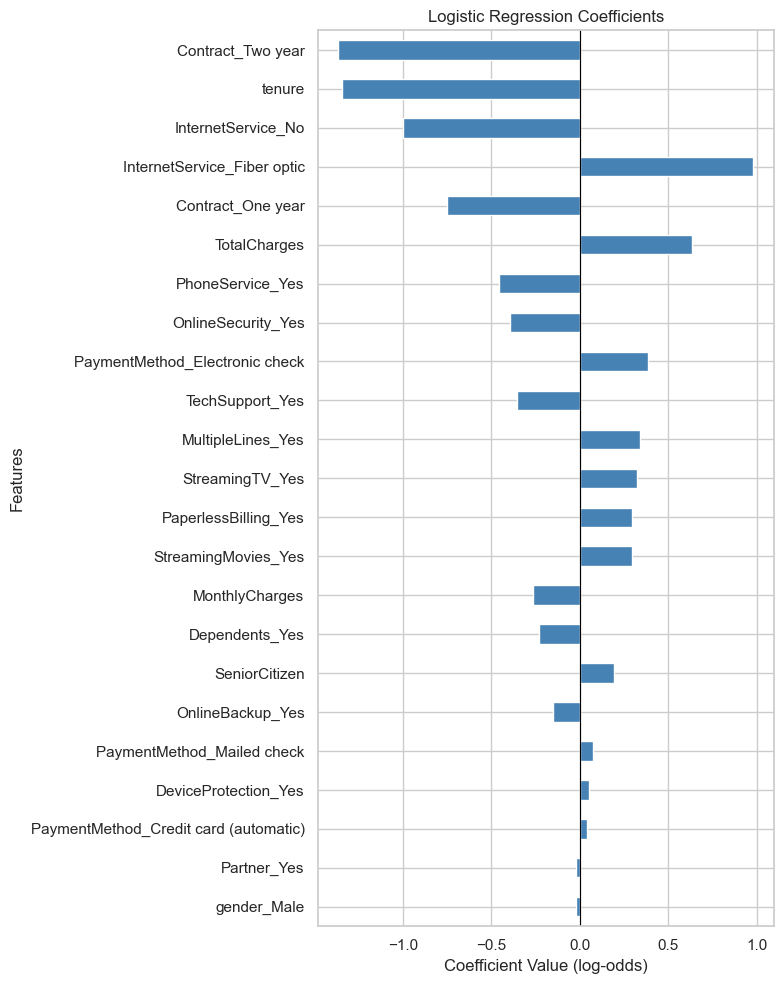

In [12]:
def plot_coefficients(log_model, columns):
    coef_df = pd.Series(log_model.coef_[0], index=columns, name="Logistic")

    # Sort by magnitude so the most impactful features are easiest to spot
    # (largest at the top)
    coef_df = coef_df.reindex(coef_df.abs().sort_values(ascending=True).index)

    coef_df.plot(kind="barh", figsize=(8, 10), color="steelblue")
    plt.title("Logistic Regression Coefficients")
    plt.xlabel("Coefficient Value (log-odds)")
    plt.ylabel("Features")
    plt.axvline(x=0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    return coef_df


coef_series = plot_coefficients(log_model, X_train_scaled.columns)

In [13]:
def plot_confusion_and_roc(y_test, y_pred, y_proba, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", label="Chance")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve - {model_name}")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

### Model Performance (with Class Imbalance Handling)

Since churn is imbalanced (~27% positive), we use `class_weight="balanced"` in `LogisticRegression`. This makes the model penalize mistakes on the minority class (churners) more heavily during training, instead of treating both classes equally. Below are this model's metrics, confusion matrix, and ROC curve.


Logistic Regression (class_weight='balanced'):
Accuracy:  0.726
Precision: 0.491
Recall:    0.799
F1:        0.608
ROC-AUC:   0.835
SeniorCitizen: 0.2047
tenure: -1.2519
MonthlyCharges: -0.3413
TotalCharges: 0.6031
gender_Male: -0.0117
Partner_Yes: -0.0365
Dependents_Yes: -0.2300
PhoneService_Yes: -0.3887
MultipleLines_Yes: 0.3126
InternetService_Fiber optic: 1.0182
InternetService_No: -1.0556
OnlineSecurity_Yes: -0.3687
OnlineBackup_Yes: -0.1294
DeviceProtection_Yes: 0.0508
TechSupport_Yes: -0.3291
StreamingTV_Yes: 0.3409
StreamingMovies_Yes: 0.3245
Contract_One year: -0.7904
Contract_Two year: -1.4548
PaperlessBilling_Yes: 0.2568
PaymentMethod_Credit card (automatic): 0.0691
PaymentMethod_Electronic check: 0.4097
PaymentMethod_Mailed check: 0.0541


/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/far/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/far/m

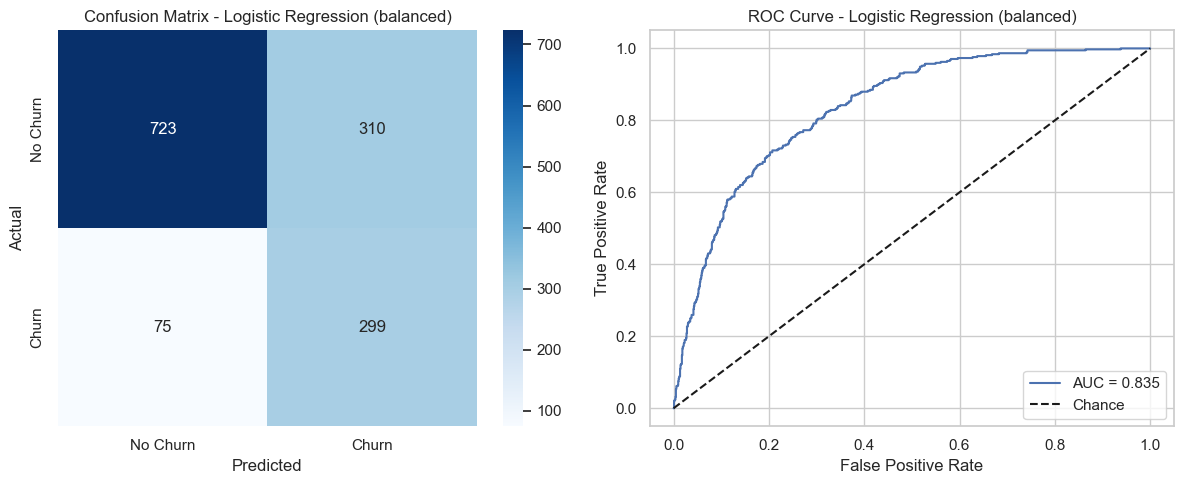

              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [14]:
# Fit logistic regression with class_weight="balanced" to handle the churn imbalance
log_model_balanced, log_pred_balanced, log_proba_balanced = evaluate_model(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression (class_weight='balanced')",
)

plot_confusion_and_roc(
    y_test, log_pred_balanced, log_proba_balanced, "Logistic Regression (balanced)"
)

Comparing the two models:

| | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Original | 0.803 | 0.648 | 0.567 | 0.605 | 0.836 |
| `class_weight="balanced"` | 0.726 | 0.491 | 0.799 | 0.608 | 0.835 |

Recall jumps a lot (0.567 → 0.799) — the balanced model catches far more of the customers who actually churn. But precision drops just as much (0.648 → 0.491), so it also flags a lot more customers who end up staying. Accuracy drops too, mostly because accuracy rewards getting the majority class (no churn) right, and the balanced model is now willing to sacrifice some of that to catch more churners. F1 stays about the same either way, and ROC-AUC barely moves, since that metric doesn't depend on where we set the decision threshold — `class_weight` mostly shifts the threshold rather than making the model fundamentally better or worse. In practice, if the business cares more about not missing potential churners (since it's usually cheaper to offer a discount to someone who wasn't going to leave than to lose a customer entirely), the balanced version's tradeoff would be worth it.

## Coefficient / Odds-Ratio Interpretation

To get proper standard errors and p-values (not just point estimates), we also fit the unregularized model with `statsmodels`, then exponentiate coefficients into odds ratios with 95% confidence intervals.

In [15]:
X_train_sm = sm.add_constant(X_train_scaled.astype(float))
logit_result = sm.Logit(y_train, X_train_sm).fit()

odds_ratios = pd.DataFrame(
    {
        "coef": logit_result.params,
        "p_value": logit_result.pvalues,
        "odds_ratio": np.exp(logit_result.params),
        "ci_lower": np.exp(logit_result.conf_int()[0]),
        "ci_upper": np.exp(logit_result.conf_int()[1]),
    }
)
odds_ratios = odds_ratios.drop(index="const").sort_values("odds_ratio", ascending=False)
odds_ratios

Optimization terminated successfully.
         Current function value: 0.411329
         Iterations 8


,coef,p_value,odds_ratio,ci_lower,ci_upper
InternetService_Fiber optic,2.681790,3.002930e-03,14.611217,2.485549,85.891562
StreamingTV_Yes,0.996566,6.933880e-03,2.708964,1.314094,5.584447
StreamingMovies_Yes,0.970593,8.766211e-03,2.639510,1.277368,5.454194
PhoneService_Yes,0.888437,2.254594e-01,2.431327,0.578036,10.226612
TotalCharges,0.706175,8.031541e-05,2.026226,1.426458,2.878173
MultipleLines_Yes,0.677459,7.262997e-04,1.968868,1.329173,2.916433
DeviceProtection_Yes,0.387045,5.286393e-02,1.472623,0.995227,2.179020
PaymentMethod_Electronic check,0.385544,2.954523e-04,1.470414,1.193342,1.811818
PaperlessBilling_Yes,0.289245,5.468896e-04,1.335419,1.133421,1.573417
SeniorCitizen,0.194560,4.101853e-02,1.214776,1.007971,1.464012


Numeric features (tenure, MonthlyCharges, and TotalCharges) were standardized, so their odds ratios represent the effect of a one-standard-deviation increase. Categorical feature odds ratios are compared to their reference category.

Important findings:

- tenure has a strong negative relationship with churn. A one-standard-deviation increase in tenure is associated with about 76% lower odds of churn.

- Customers with one-year and two-year contracts have lower churn odds compared with month-to-month customers.

- Customers using electronic check payments and paperless billing show higher churn odds.

- Some features, such as InternetService and MonthlyCharges, should be interpreted carefully because they have high uncertainty and were affected by multicollinearity. These variables may not have stable individual effects, but together they suggest that service type and pricing are related to churn risk.

## Limitation of Logistic Regression for Churn

One limitation of logistic regression is that it assumes a linear relationship between predictors and the log-odds of churn. In our analysis, MonthlyCharges did not fully satisfy this assumption, which means the model may not capture its effect accurately. A more flexible model, such as GAM, could better capture nonlinear patterns.